In [61]:
import pandas as pd
import numpy as np
import missingno as msno

In [62]:
df = pd.read_csv("exemplos_limpeza_dados.csv")
print(df)

    Country   Age   Salary Grade Purchased
0    France  44.0  72000.0   1st        No
1    France  44.0  72000.0   1st        No
2     Spain  27.0  48000.0   1st       Yes
3   Germany  30.0  54000.0   3th        No
4     Spain  38.0  61000.0   1st        No
5   Germany  40.0      NaN   2nd       Yes
6   Germany  40.0      NaN   2nd       Yes
7    France  35.0  58000.0   2nd       Yes
8     Spain   NaN  52000.0   1st        No
9    France  48.0  79000.0   3th       Yes
10  Germany  50.0  83000.0   2nd        No
11   France  37.0  67000.0   3th       Yes


In [63]:
df.sample(10)

,Country,Age,Salary,Grade,Purchased
10,Germany,50.0,83000.0,2nd,No
7,France,35.0,58000.0,2nd,Yes
11,France,37.0,67000.0,3th,Yes
8,Spain,NaN,52000.0,1st,No
9,France,48.0,79000.0,3th,Yes
1,France,44.0,72000.0,1st,No
2,Spain,27.0,48000.0,1st,Yes
5,Germany,40.0,NaN,2nd,Yes
6,Germany,40.0,NaN,2nd,Yes
3,Germany,30.0,54000.0,3th,No


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    12 non-null     object 
 1   Age        11 non-null     float64
 2   Salary     10 non-null     float64
 3   Grade      12 non-null     object 
 4   Purchased  12 non-null     object 
dtypes: float64(2), object(3)
memory usage: 612.0+ bytes


In [65]:
df.describe()

,Age,Salary
count,11.000000,10.000000
mean,39.363636,64600.000000
std,7.060775,11852.800888
min,27.000000,48000.000000
25%,36.000000,55000.000000
50%,40.000000,64000.000000
75%,44.000000,72000.000000
max,50.000000,83000.000000


<Axes: >

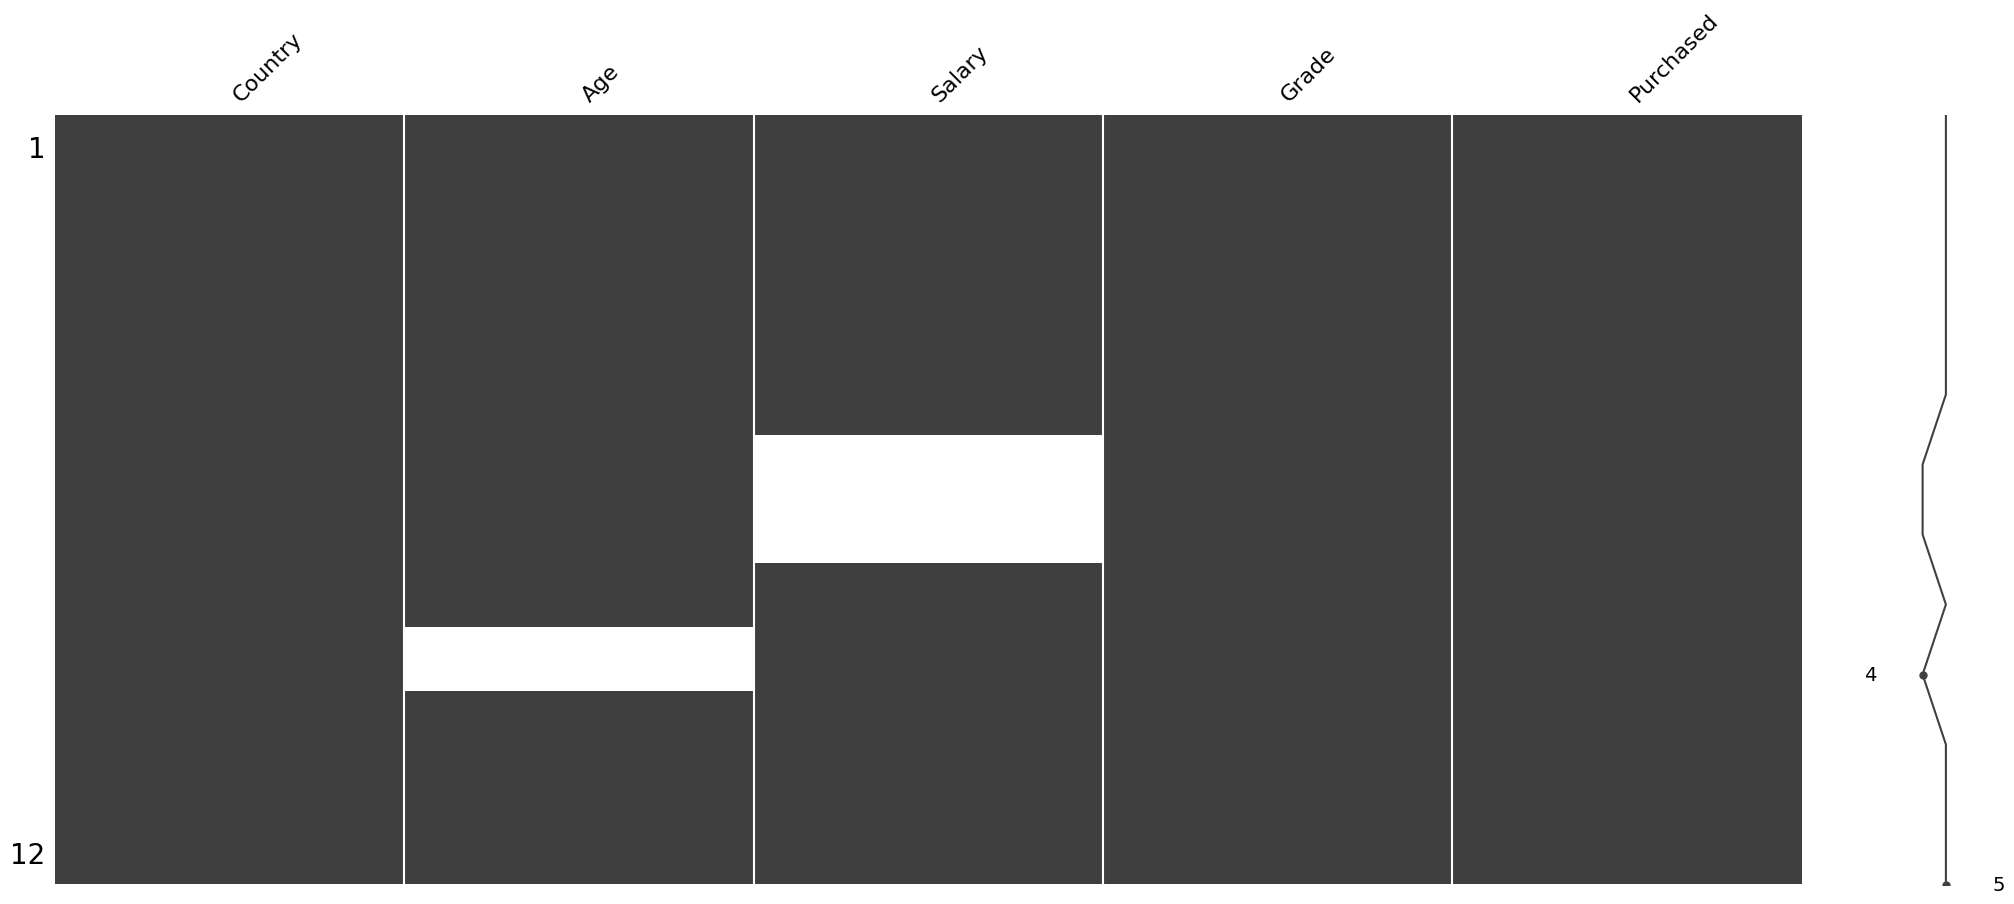

In [66]:
msno.matrix(df)

In [67]:
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Salary"].fillna(df["Salary"].median(), inplace=True)

print(df)

    Country        Age   Salary Grade Purchased
0    France  44.000000  72000.0   1st        No
1    France  44.000000  72000.0   1st        No
2     Spain  27.000000  48000.0   1st       Yes
3   Germany  30.000000  54000.0   3th        No
4     Spain  38.000000  61000.0   1st        No
5   Germany  40.000000  64000.0   2nd       Yes
6   Germany  40.000000  64000.0   2nd       Yes
7    France  35.000000  58000.0   2nd       Yes
8     Spain  39.363636  52000.0   1st        No
9    France  48.000000  79000.0   3th       Yes
10  Germany  50.000000  83000.0   2nd        No
11   France  37.000000  67000.0   3th       Yes


/tmp/ipykernel_1338/426506810.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_1338/426506810.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [68]:
print(f"A média das idade é {df["Age"].mean()} e a mediana é {df["Salary"].median()}")

A média das idade é 39.36363636363637 e a mediana é 64000.0


Tratando dados categóricos - ORDINAIS

In [69]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

print(df["Purchased"].unique())

le = LabelEncoder()

df["Purchased_encoder"] = le.fit_transform(df["Purchased"])
df["Grade_encoder"] = le.fit_transform(df["Grade"])
df

['No' 'Yes']


,Country,Age,Salary,Grade,Purchased,Purchased_encoder,Grade_encoder
0,France,44.000000,72000.0,1st,No,0,0
1,France,44.000000,72000.0,1st,No,0,0
2,Spain,27.000000,48000.0,1st,Yes,1,0
3,Germany,30.000000,54000.0,3th,No,0,2
4,Spain,38.000000,61000.0,1st,No,0,0
5,Germany,40.000000,64000.0,2nd,Yes,1,1
6,Germany,40.000000,64000.0,2nd,Yes,1,1
7,France,35.000000,58000.0,2nd,Yes,1,1
8,Spain,39.363636,52000.0,1st,No,0,0
9,France,48.000000,79000.0,3th,Yes,1,2


Tratando Dados Categóricos -  Nominais

In [70]:
aux = pd.get_dummies(df["Country"])
final = pd.concat([df, aux], axis=1)
final

,Country,Age,Salary,Grade,Purchased,Purchased_encoder,Grade_encoder,France,Germany,Spain
0,France,44.000000,72000.0,1st,No,0,0,True,False,False
1,France,44.000000,72000.0,1st,No,0,0,True,False,False
2,Spain,27.000000,48000.0,1st,Yes,1,0,False,False,True
3,Germany,30.000000,54000.0,3th,No,0,2,False,True,False
4,Spain,38.000000,61000.0,1st,No,0,0,False,False,True
5,Germany,40.000000,64000.0,2nd,Yes,1,1,False,True,False
6,Germany,40.000000,64000.0,2nd,Yes,1,1,False,True,False
7,France,35.000000,58000.0,2nd,Yes,1,1,True,False,False
8,Spain,39.363636,52000.0,1st,No,0,0,False,False,True
9,France,48.000000,79000.0,3th,Yes,1,2,True,False,False


In [71]:
final.drop(columns=["Country","Purchased", "Grade"], inplace = True)
final

,Age,Salary,Purchased_encoder,Grade_encoder,France,Germany,Spain
0,44.000000,72000.0,0,0,True,False,False
1,44.000000,72000.0,0,0,True,False,False
2,27.000000,48000.0,1,0,False,False,True
3,30.000000,54000.0,0,2,False,True,False
4,38.000000,61000.0,0,0,False,False,True
5,40.000000,64000.0,1,1,False,True,False
6,40.000000,64000.0,1,1,False,True,False
7,35.000000,58000.0,1,1,True,False,False
8,39.363636,52000.0,0,0,False,False,True
9,48.000000,79000.0,1,2,True,False,False


In [72]:
final.to_csv("dados_tratados.csv")

In [73]:
sc = StandardScaler()
final_padronizado = sc.fit_transform(final)
final_padronizado

array([[ 0.7193094 ,  0.73047713, -1.        , -1.04257207,  1.18321596,
        -0.70710678, -0.57735027],
       [ 0.7193094 ,  0.73047713, -1.        , -1.04257207,  1.18321596,
        -0.70710678, -0.57735027],
       [-1.91815839, -1.60704969,  1.        , -1.04257207, -0.84515425,
        -0.70710678,  1.73205081],
       [-1.4527229 , -1.02266798, -1.        ,  1.4596009 , -0.84515425,
         1.41421356, -0.57735027],
       [-0.21156159, -0.34088933, -1.        , -1.04257207, -0.84515425,
        -0.70710678,  1.73205081],
       [ 0.09872874, -0.04869848,  1.        ,  0.20851441, -0.84515425,
         1.41421356, -0.57735027],
       [ 0.09872874, -0.04869848,  1.        ,  0.20851441, -0.84515425,
         1.41421356, -0.57735027],
       [-0.67699708, -0.63308018,  1.        ,  0.20851441,  1.18321596,
        -0.70710678, -0.57735027],
       [ 0.        , -1.21746188, -1.        , -1.04257207, -0.84515425,
        -0.70710678,  1.73205081],
       [ 1.33989005,  1.4122

In [74]:
mm = MinMaxScaler(feature_range=(0,1))
final_normalizado = mm.fit_transform(final)
final_normalizado

array([[0.73913043, 0.68571429, 0.        , 0.        , 1.        ,
        0.        , 0.        ],
       [0.73913043, 0.68571429, 0.        , 0.        , 1.        ,
        0.        , 0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 1.        ],
       [0.13043478, 0.17142857, 0.        , 1.        , 0.        ,
        1.        , 0.        ],
       [0.47826087, 0.37142857, 0.        , 0.        , 0.        ,
        0.        , 1.        ],
       [0.56521739, 0.45714286, 1.        , 0.5       , 0.        ,
        1.        , 0.        ],
       [0.56521739, 0.45714286, 1.        , 0.5       , 0.        ,
        1.        , 0.        ],
       [0.34782609, 0.28571429, 1.        , 0.5       , 1.        ,
        0.        , 0.        ],
       [0.53754941, 0.11428571, 0.        , 0.        , 0.        ,
        0.        , 1.        ],
       [0.91304348, 0.88571429, 1.        , 1.        , 1.        ,
        0.        , 0. 

In [75]:
df_padronizado = pd.DataFrame(final_padronizado, columns=final.columns)
df_padronizado

,Age,Salary,Purchased_encoder,Grade_encoder,France,Germany,Spain
0,0.719309,0.730477,-1.0,-1.042572,1.183216,-0.707107,-0.577350
1,0.719309,0.730477,-1.0,-1.042572,1.183216,-0.707107,-0.577350
2,-1.918158,-1.607050,1.0,-1.042572,-0.845154,-0.707107,1.732051
3,-1.452723,-1.022668,-1.0,1.459601,-0.845154,1.414214,-0.577350
4,-0.211562,-0.340889,-1.0,-1.042572,-0.845154,-0.707107,1.732051
5,0.098729,-0.048698,1.0,0.208514,-0.845154,1.414214,-0.577350
6,0.098729,-0.048698,1.0,0.208514,-0.845154,1.414214,-0.577350
7,-0.676997,-0.633080,1.0,0.208514,1.183216,-0.707107,-0.577350
8,0.000000,-1.217462,-1.0,-1.042572,-0.845154,-0.707107,1.732051
9,1.339890,1.412256,1.0,1.459601,1.183216,-0.707107,-0.577350


In [76]:
df_nomalizado = pd.DataFrame(final_normalizado, columns=final.columns)
df_nomalizado

,Age,Salary,Purchased_encoder,Grade_encoder,France,Germany,Spain
0,0.739130,0.685714,0.0,0.0,1.0,0.0,0.0
1,0.739130,0.685714,0.0,0.0,1.0,0.0,0.0
2,0.000000,0.000000,1.0,0.0,0.0,0.0,1.0
3,0.130435,0.171429,0.0,1.0,0.0,1.0,0.0
4,0.478261,0.371429,0.0,0.0,0.0,0.0,1.0
5,0.565217,0.457143,1.0,0.5,0.0,1.0,0.0
6,0.565217,0.457143,1.0,0.5,0.0,1.0,0.0
7,0.347826,0.285714,1.0,0.5,1.0,0.0,0.0
8,0.537549,0.114286,0.0,0.0,0.0,0.0,1.0
9,0.913043,0.885714,1.0,1.0,1.0,0.0,0.0


In [77]:
df_nomalizado.to_csv("dados_tratados_normalizados.csv")
df_padronizado.to_csv("dados_tratados_padronizados.csv")